# Credit Card Fraud Detection

**End-to-end machine learning pipeline for detecting fraudulent credit card transactions.**

## Problem Statement
Credit card fraud causes billions in losses annually. This project builds a classification model that identifies fraudulent transactions from a highly imbalanced dataset (~0.17% fraud rate), and uses SHAP explainability to make predictions fully auditable.

## Dataset
- **Source:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- **Size:** 284,807 transactions × 31 columns
- **Features:** `Time`, `Amount`, and 28 anonymised PCA components (V1–V28)
- **Target:** `Class` — 0 = Legitimate, 1 = Fraud

## Pipeline Overview
| Stage | Description |
|-------|-------------|
| 1. Data Collection | Load and inspect raw data |
| 2. Data Cleaning | Handle duplicates, types, outliers |
| 3. EDA | Class imbalance, amount, time, feature distributions |
| 4. Feature Engineering | Scale Amount and Time |
| 5. Data Preparation | Train-test split with stratification |
| 6. Model Building | Train 4 classifiers, select best by ROC-AUC |
| 7. Model Evaluation | Threshold tuning, confusion matrix, ROC curve |
| 8. Feature Importance | XGBoost built-in + SHAP values |
| 9. Model Explainability | Waterfall and dependence plots |
| 10. Business Recommendations | Actionable fraud-team guidance |
| 11. Conclusion | Results, limitations, future work |

In [43]:
# Standard library
import pandas as pd
import numpy as np

# Visualisation library
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modelling library
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, classification_report, roc_auc_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)
import xgboost as xgb
from xgboost import XGBClassifier

# Explainability library
import shap

print('All libraries imported successfully.')

All libraries imported successfully.


## **1. Data Collection**

In [44]:
# Download the dataset from Kaggle:
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# Place creditcard.csv in the same folder as this notebook.

df = pd.read_csv('creditcard.csv')

# Preview the first few rows to understand structure
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [45]:
# Check number of rows and columns
print(df.shape)

(284807, 31)


In [46]:
# Quick overview of all columns and their data type
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## **2. Data Cleaning**

### **2.1 Missing values**

In [47]:
# Check for nulls and duplicates
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### **2.2 Duplicate Records**

In [48]:
# Count duplicate rows because duplicates can bias model training
print(df.duplicated().sum())

1081


In [49]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Confirm if duplicates have been removed
print(df.duplicated().sum())

0


### **2.3 Data Types**

In [50]:
# Verify if all columns are in their expected data 
# V1-V28 and Amount should be float, class should be int
print(df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


### **2.4 Column Names**

In [51]:
# Standardize column names: strip whitespace, lowercase, replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

### **2.5 Basic Sanity Check**

In [52]:
# Final shape after cleaning
print(df.shape)

(283726, 31)


In [53]:
# Summary statistics to spot anything unusual
df.describe()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


### **2.6 Outlier Check on V-features**

In [54]:
# Check how extreme the outliers are relative to std deviation
for col in ["v2", "v5", "v7"]:
    mean = df[col].mean()
    std = df[col].std()
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"{col} | min: {min_val:.2f} | max: {max_val:.2f} | "
          f"min z-score: {(min_val - mean)/std:.2f} | max z-score: {(max_val - mean)/std:.2f}")

v2 | min: -72.72 | max: 22.06 | min z-score: -44.16 | max z-score: 13.40
v5 | min: -113.74 | max: 34.80 | min z-score: -82.60 | max z-score: 25.27
v7 | min: -43.56 | max: 120.59 | min z-score: -35.48 | max z-score: 98.23


## **3. Exploratory Data Analysis (EDA)**

### **3.1 Class Distribution**

In [55]:
# Count legitimate vs fraudulent transactions
print(df['class'].value_counts())

# As percentage
print(df['class'].value_counts(normalize=True)*100) 

class
0    283253
1       473
Name: count, dtype: int64
class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


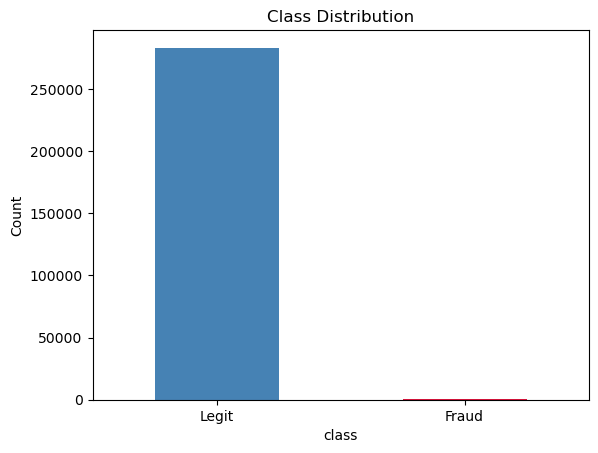

In [56]:
# Visual: bar chart of class imbalance
df["class"].value_counts().plot(kind="bar", color=["steelblue", "crimson"])
plt.xticks([0, 1], ["Legit", "Fraud"], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

### **3.2 Transaction Amount Analysis**

In [57]:
# Summary stats for amount split by class
print(df.groupby('class')['amount'].describe())

          count        mean         std  min   25%    50%     75%       max
class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [58]:
#  Mean amount by class
print(df.groupby('class')['amount'].mean())

class
0     88.413575
1    123.871860
Name: amount, dtype: float64


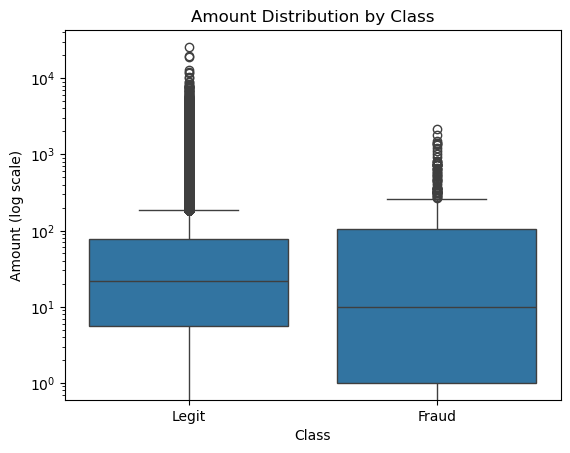

In [59]:
# Boxplot on raw amount to spot outliers by class
# Log scale prevents extreme values from collapsing the plot
sns.boxplot(x="class", y="amount", data=df, showfliers=True)
plt.yscale("log")
plt.xticks([0, 1], ["Legit", "Fraud"])
plt.title("Amount Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Amount (log scale)")
plt.show()

### **3.3 Time Analysis**

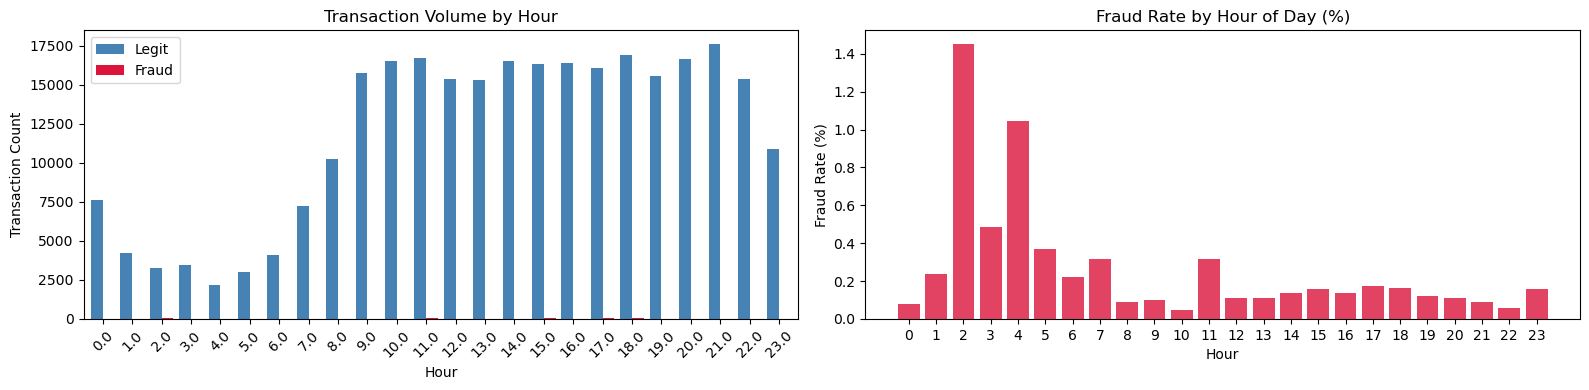

Peak fraud hour: 2.0 (1.451%)


In [60]:
# Convert raw seconds into hour-of-day (0-23)
df["hour"] = (df["time"] // 3600) % 24

# Fraud rate per hour: shows WHEN fraud is most likely, not just how many transactions
# Raw counts are misleading because fraud is so rare vs legitimate transactions
hourly = df.groupby("hour")["class"].agg(["sum", "count"])
hourly["fraud_rate"] = (hourly["sum"] / hourly["count"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: raw counts (legit dominates — included for context)
df.groupby(["hour", "class"]).size().unstack().plot(
    kind="bar", ax=axes[0], color=["steelblue", "crimson"], width=0.8
)
axes[0].set_title("Transaction Volume by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Transaction Count")
axes[0].legend(["Legit", "Fraud"])
axes[0].tick_params(axis="x", rotation=45)

# Right: fraud rate per hour (the meaningful signal)
axes[1].bar(hourly.index, hourly["fraud_rate"], color="crimson", alpha=0.8)
axes[1].set_title("Fraud Rate by Hour of Day (%)")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

print("Peak fraud hour:", hourly["fraud_rate"].idxmax(),
      f"({hourly['fraud_rate'].max():.3f}%)")

### **3.4 V1-V28 Feature Distribution by Class**

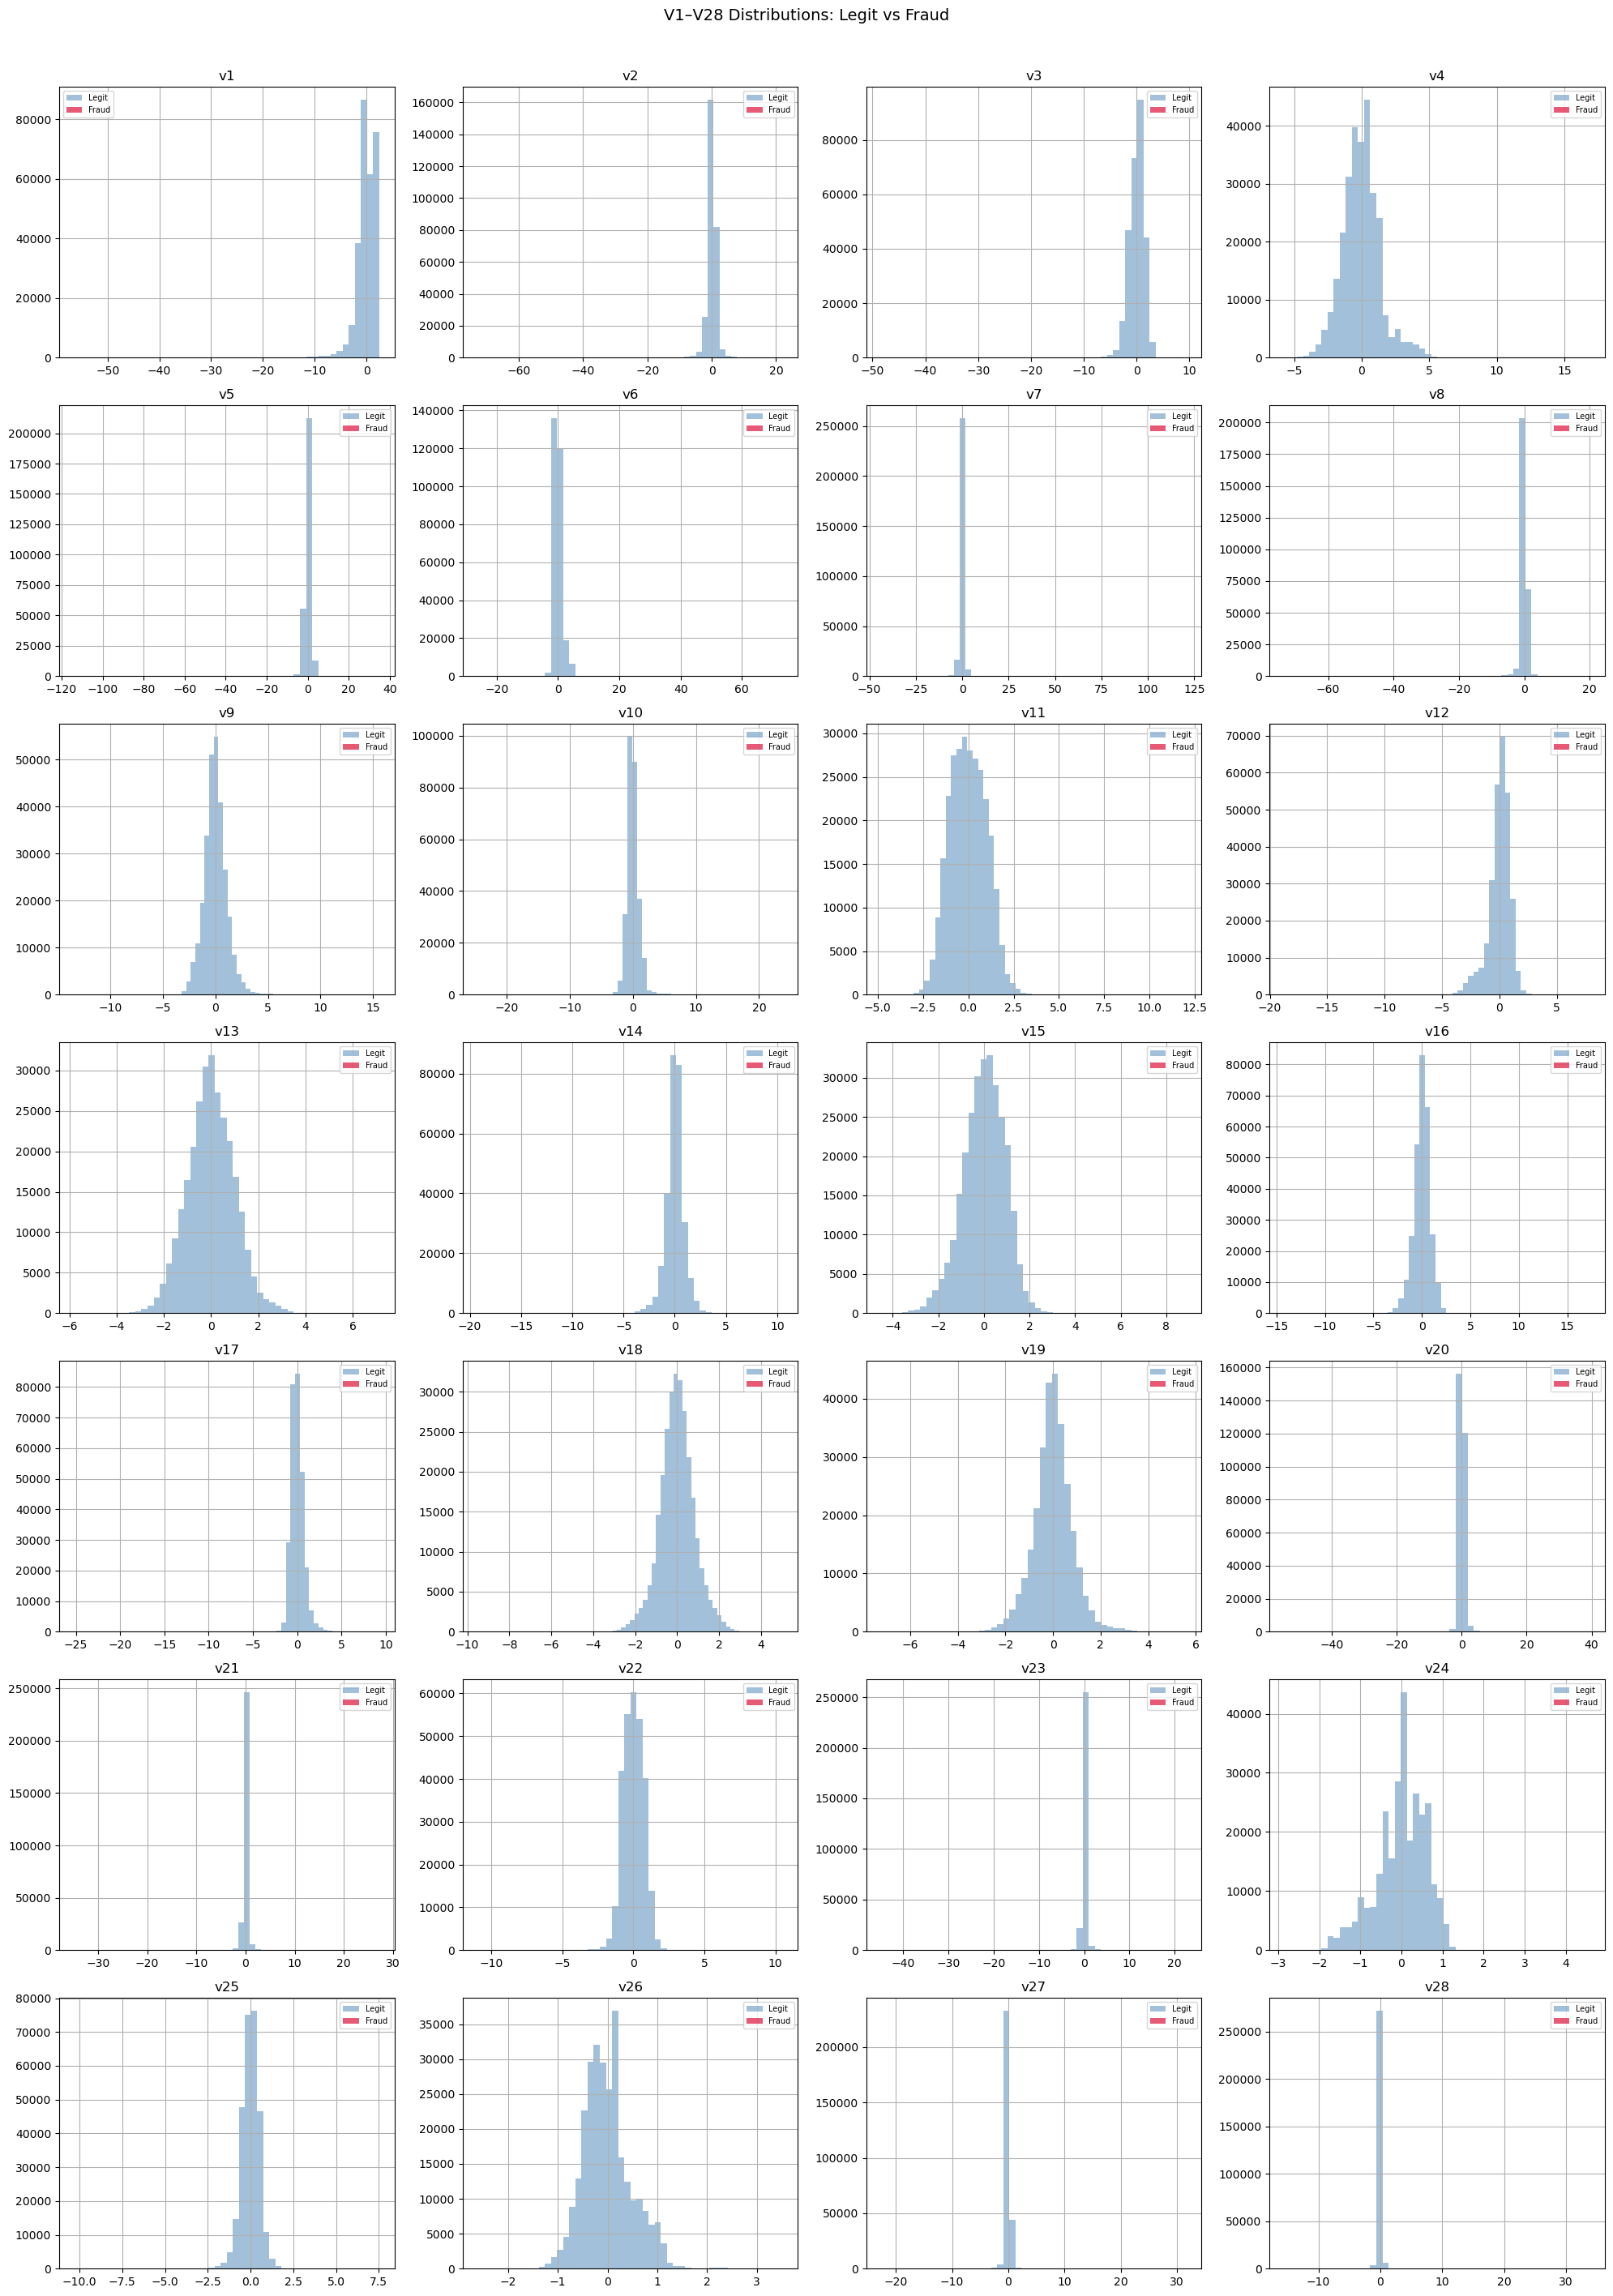

In [61]:
# Plot each PCA component's distribution for legit vs fraud
# Features where the two distributions diverge most are the strongest fraud separators
v_features = [f"v{i}" for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
for i, col in enumerate(v_features):
    ax = axes[i // 4][i % 4]
    df[df["class"] == 0][col].hist(ax=ax, bins=50, alpha=0.5,
                                    color="steelblue", label="Legit")
    df[df["class"] == 1][col].hist(ax=ax, bins=50, alpha=0.7,
                                    color="crimson", label="Fraud")
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.suptitle("V1–V28 Distributions: Legit vs Fraud", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### **3.5 Feature Correlation with Target**

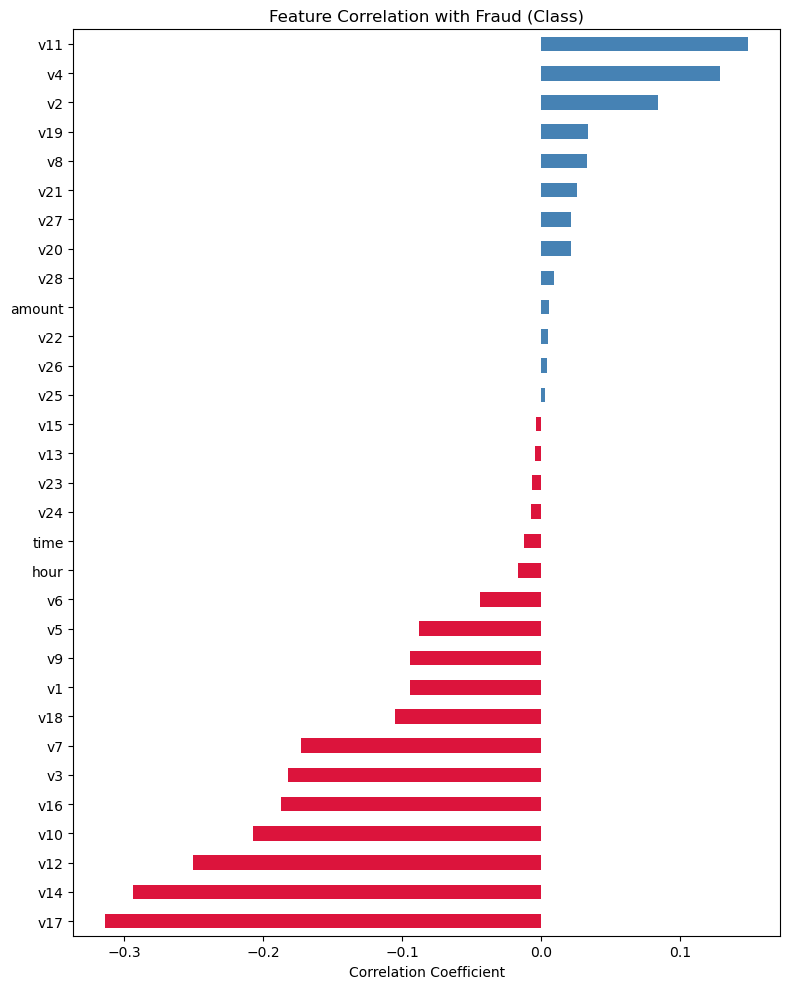

In [62]:
# Compute correlation of every feature against the class label
# Negative correlation: higher value → less likely fraud (and vice versa)
# Helps identify which features carry the strongest predictive signal
corr = df.corr()["class"].drop("class").sort_values()

# Colour bars by direction: red = negative, blue = positive
corr.plot(kind="barh", figsize=(8, 10), color=["crimson" if v < 0 else "steelblue" for v in corr])
plt.title("Feature Correlation with Fraud (Class)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

## **4. Feature Engineering**

### **4.1 Scale amount and time**

In [63]:
scaler = StandardScaler()
df['amount_scaled'] = scaler.fit_transform(df[['amount']])
df['time_scaled']   = scaler.fit_transform(df[['time']])

### **4.2 Drop original unscaled columns**

In [64]:
df.drop(columns=['time', 'amount'], inplace=True)

In [65]:
# Recheck df shape and columns
print(df.shape)
print(df.columns.tolist())

(283726, 32)
['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'class', 'hour', 'amount_scaled', 'time_scaled']


## **5. Data Preparation**

### **5.1 Define Features and Target**

In [66]:
X = df.drop('class', axis=1)
y = df['class']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())
print("Fraud percentage:", round(y.mean() * 100, 2), "%")

Features shape: (283726, 31)
Target distribution:
 class
0    283253
1       473
Name: count, dtype: int64
Fraud percentage: 0.17 %


### **5.2 Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (226980, 31)
Test size: (56746, 31)


## **6. Model Building**

### **6.1 Define Models**

Four classification models are trained to detect fraudulent transactions.
Class imbalance is handled directly using `class_weight='balanced'` for
sklearn models, and `scale_pos_weight` for XGBoost, both approaches
penalize misclassification of the minority class (fraud) more heavily,
eliminating the need for resampling techniques like SMOTE.

### **6.2 Train and Evaluate Models**

Each model is trained on the original imbalanced training data and evaluated
on the test set using:
- **Classification Report** — precision, recall, F1-score per class
- **ROC-AUC Score** — measures overall ability to distinguish fraud from non-fraud

> ⚠️ Accuracy is not a reliable metric here due to class imbalance (~99.8% non-fraud).
> Focus on **Recall** and **F1-score for class 1 (fraud)**.

In [68]:
# Model dictionary for comparison
# For XGBoost: scale_pos_weight = majority count / minority count
neg, pos = y_train.value_counts()
scale = neg / pos
print(f"scale_pos_weight: {round(scale, 2)}")

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=10),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_jobs=-1, n_estimators=100),
    "XGBoost": XGBClassifier(scale_pos_weight=scale, n_jobs=-1,random_state=42,eval_metric='logloss'),
}

scale_pos_weight: 599.48


In [69]:
# Train each model with class-weight balancing, evaluate on original test set
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probability of fraud (class 1)
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))


Model: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746

ROC-AUC: 0.9686

Model: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.23      0.78      0.36        95

    accuracy                           1.00     56746
   macro avg       0.62      0.89      0.68     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.8886

Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.71      0.82        95

    accuracy                           1.00     56746
   macro avg       0.99 

### **6.3 ROC Curve Comparison**

The ROC curve plots True Positive Rate (Recall) against False Positive Rate across all thresholds. A model that perfectly separates fraud from legitimate transactions would have AUC = 1.0. The plot below compares all four models visually.

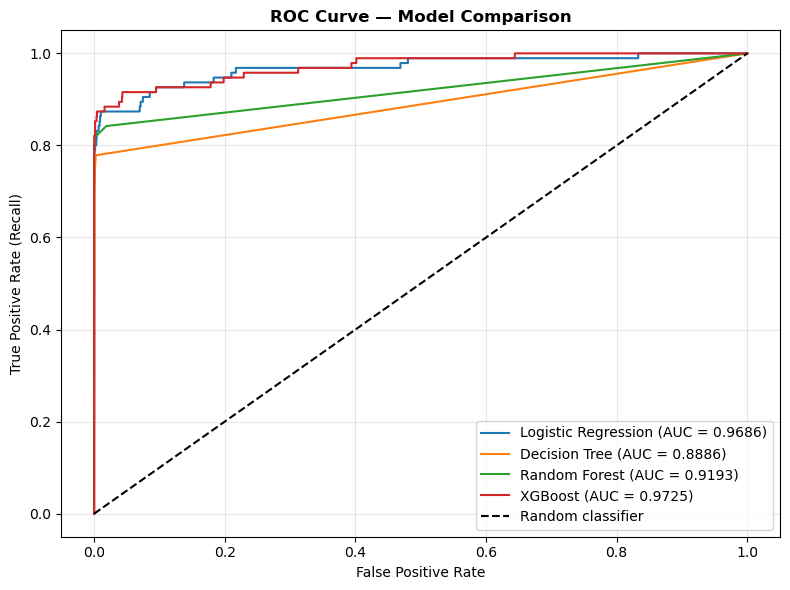

In [70]:
# ROC curve comparison for all four models
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Model Comparison', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **6.4 Best Model Selection**

In [71]:
# Collect results from all trained models
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "F1 (fraud)": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)}

In [72]:
# Build comparison table
results_df = pd.DataFrame(results).T.sort_values("ROC-AUC", ascending=False)
print(results_df)

                     F1 (fraud)  ROC-AUC
XGBoost                  0.8506   0.9725
Logistic Regression      0.1042   0.9686
Random Forest            0.8171   0.9193
Decision Tree            0.3584   0.8886


In [73]:
# Select best model by ROC-AUC
best_model_name = results_df["ROC-AUC"].idxmax()
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name}")


Best Model: XGBoost


## **7. Model Evaluation**

### **7.1 Threshold Tuning**

The default decision threshold is 0.5. Lowering it increases Recall 
(catches more fraud) at the cost of Precision (more false alarms).
We use the Precision-Recall curve to find the optimal threshold that maximises F1

In [74]:
# Get predicted probabilities from best model
y_prob_best = best_model.predict_proba(X_test)[:, 1]

In [75]:
# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_best)

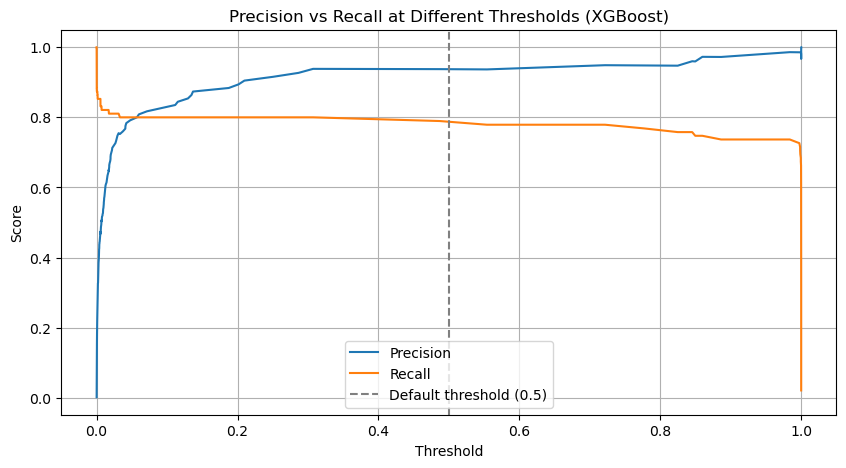

In [76]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.axvline(x=0.5, color='gray', linestyle='--', label="Default threshold (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title(f"Precision vs Recall at Different Thresholds ({best_model_name})")
plt.legend()
plt.grid(True)
plt.show()

In [77]:
# Find best threshold where F1 is maximised
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall:    {recalls[best_idx]:.4f}")
print(f"F1:        {f1_scores[best_idx]:.4f}")

Best Threshold: 0.3072
Precision: 0.9383
Recall:    0.8000
F1:        0.8636


### **7.2 Applying the Tuned Threshold**

In [78]:
# Apply tuned threshold
y_pred_tuned = (y_prob_best >= best_threshold).astype(int)
print("\nTuned Classification Report:")
print(classification_report(y_test, y_pred_tuned))


Tuned Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.80      0.86        95

    accuracy                           1.00     56746
   macro avg       0.97      0.90      0.93     56746
weighted avg       1.00      1.00      1.00     56746



### **7.3 Confusion Matrix**

The confusion matrix shows the exact counts of correct and incorrect predictions at the tuned threshold. In fraud detection, **False Negatives** (missed fraud) are the most costly outcome.

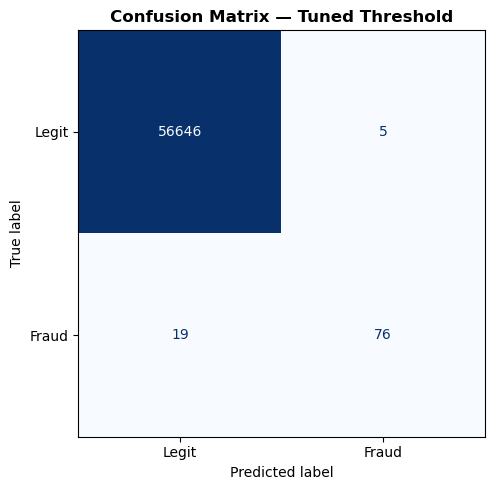

True Negatives  (correctly flagged legit):  56,646
False Positives (legit flagged as fraud):   5
False Negatives (missed fraud cases):       19
True Positives  (correctly caught fraud):   76


In [79]:
# Confusion matrix — visualises true positives, false positives,
# true negatives, and false negatives at the tuned threshold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Tuned Threshold", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly flagged legit):  {tn:,}")
print(f"False Positives (legit flagged as fraud):   {fp:,}")
print(f"False Negatives (missed fraud cases):       {fn:,}")
print(f"True Positives  (correctly caught fraud):   {tp:,}")

### **7.4 Threshold Tuning Results**

Applying the tuned threshold improved model performance on the minority class (fraud):

- **Recall (Class 1):** Increased, meaning the model now catches more actual fraud cases
- **F1-score (Class 1):** Improved to **0.86**, reflecting a better precision-recall balance
- **Precision (Class 1):** Remained high at 0.94. The increase in recall came at only a small cost to precision, meaning 94% of flagged transactions are still genuine fraud

In fraud detection, **recall is the priority metric** because missing a fraud case is costlier than a false alarm. The tuned threshold shifts the decision boundary to favour catching more frauds, which is the right trade-off for this domain.

## **8. Feature Importance**

### **8.1 XGBoost Built-in Importance**

XGBoost exposes three importance metrics for each feature:

| Metric | What it measures |
|--------|-----------------|
| **Weight** | How often a feature appears as a split node across all trees |
| **Gain** | Average improvement in loss when a feature is used to split |
| **Cover** | Average number of samples affected by splits on that feature |

*Gain* is generally the most informative metric because a feature with high gain consistently reduces 
prediction error wherever it appears.

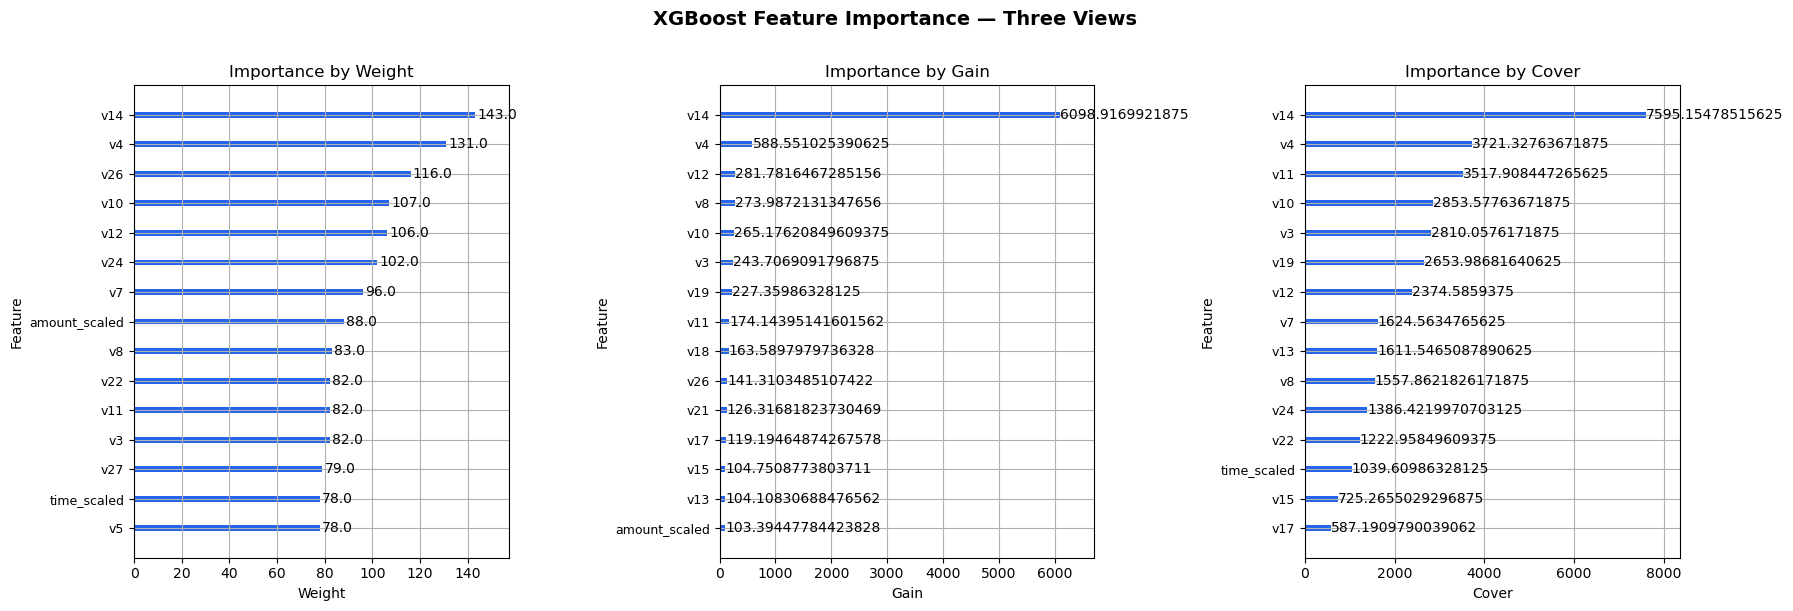

In [80]:
importance_types = ["weight", "gain", "cover"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, imp_type in zip(axes, importance_types):
    xgb.plot_importance(
        best_model,
        importance_type=imp_type,
        max_num_features=15,
        ax=ax,
        title=f"Importance by {imp_type.capitalize()}",
        xlabel=imp_type.capitalize(),
        ylabel="Feature",
        color="#2563EB",
    )
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("XGBoost Feature Importance — Three Views", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_importance_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

> **Observation:** The three views largely agree on the top features, with gain 
> being the definitive signal. Features that rank highly across all three metrics 
> are the most robustly important: they are used often, reduce error consistently, 
> and affect a large share of predictions.

In [81]:
# Top-15 gain table
gain_scores = best_model.get_booster().get_score(importance_type="gain")
importance_df = (
    pd.DataFrame(gain_scores.items(), columns=["Feature", "Gain"])
    .sort_values("Gain", ascending=False)
    .reset_index(drop=True)
)
importance_df["Rank"] = importance_df.index + 1
importance_df["Gain"] = importance_df["Gain"].round(2)
print("\nTop 15 Features by Gain:")
print(importance_df.head(15).to_string(index=False))


Top 15 Features by Gain:
      Feature    Gain  Rank
          v14 6098.92     1
           v4  588.55     2
          v12  281.78     3
           v8  273.99     4
          v10  265.18     5
           v3  243.71     6
          v19  227.36     7
          v11  174.14     8
          v18  163.59     9
          v26  141.31    10
          v21  126.32    11
          v17  119.19    12
          v15  104.75    13
          v13  104.11    14
amount_scaled  103.39    15


> **Observation:** `v14` is the single most dominant feature by a large margin:
> its gain score (~6,098) is roughly 10× that of the next best feature (`v4`, ~588),
> indicating it alone drives the largest reduction in prediction error across all trees.
> `v4`, `v12`, `v10`, and `v3` form a secondary tier, ranking consistently across
> all three metrics. `amount_scaled` appears in weight and gain but not in the top
> cover features, suggesting it creates impactful but narrower splits.

---

### **8.2 SHAP Values**

Built-in importance scores reveal *which* features matter but not *how* they 
influence predictions. SHAP values address this gap. Grounded in cooperative game theory, 
they assign each feature a contribution score for every individual prediction, 
showing exactly how much each feature pushed a prediction toward fraud or away from it.

##### Global Importance (Mean |SHAP|)

The bar chart below ranks features by their **average absolute SHAP value** across 
the test set. A higher value means that feature shifted the model's output further 
from the base rate on average, and this should align with the gain rankings above.

##### Direction & Spread (Beeswarm Plot)

Each dot represents one test observation:

| Visual element | Meaning |
|----------------|---------|
| **X-axis position (positive)** | Feature pushed prediction toward fraud |
| **X-axis position (negative)** | Feature pushed prediction toward legitimate |
| **Colour (red)** | High raw value of that feature for this sample |
| **Colour (blue)** | Low raw value of that feature for this sample |
| **Vertical spread** | Density — many similar predictions cluster together |

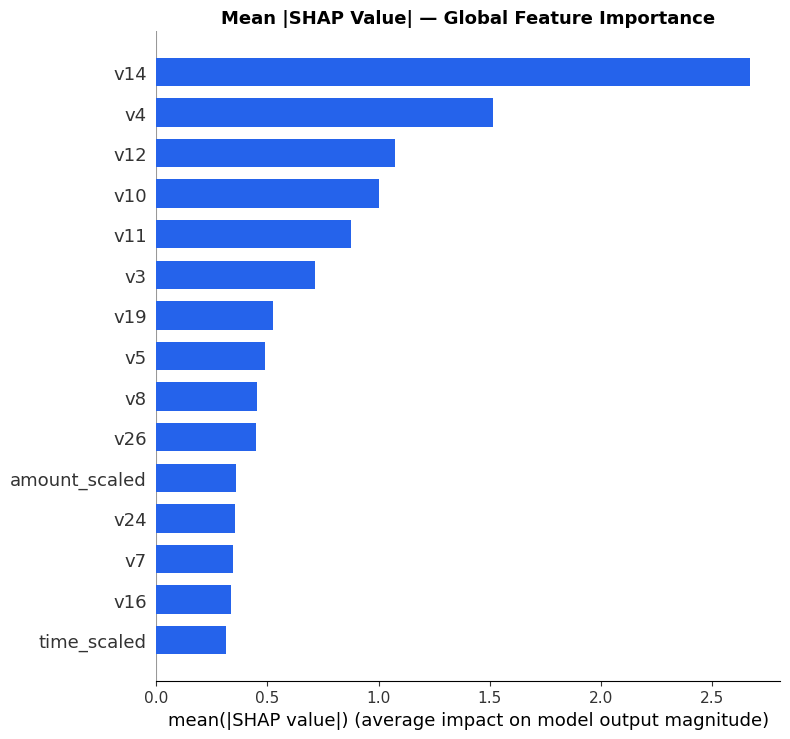

In [82]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Bar plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False,
                  color="#2563EB", max_display=15)
plt.title("Mean |SHAP Value| — Global Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

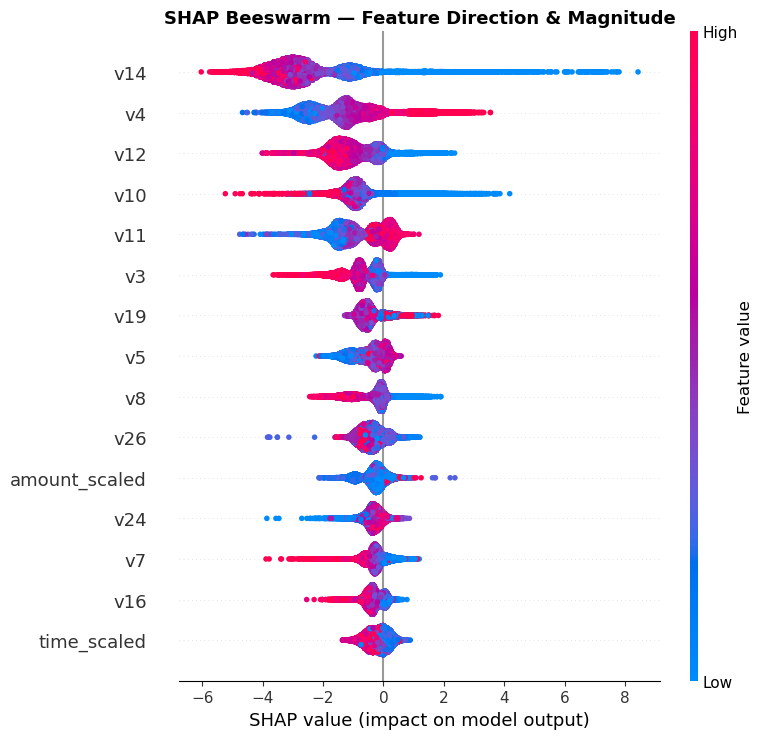

In [83]:
# Beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False, max_display=15)
plt.title("SHAP Beeswarm — Feature Direction & Magnitude", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

> **Key insight from the beeswarm:**
>
> - **`v14`** — blue dots (low values) extend to the right (positive SHAP), meaning 
>   *low values of v14 push predictions toward fraud*. Red dots sit on the left, 
>   confirming high v14 = legitimate. This is the strongest and clearest directional 
>   signal in the entire model.
>
> - **`v4`** — the opposite pattern: red dots (high values) extend right, so 
>   *high values of v4 increase fraud risk*.
>
> - **`v12`** — red dots on the left, blue extending right meaning that *low v12 values 
>   are associated with fraud*.
>
> - **`v10`** — wide spread in both directions, suggesting this feature has a 
>   more complex, non-linear relationship with fraud.
>
> - **`v11`** — red dots extend right, so *high v11 values push toward fraud*.
>
> The SHAP bar plot confirms what gain told us that `v14` alone accounts for more 
> average model impact than the next three features combined. The beeswarm adds 
> the critical directional layer that gain scores cannot provide.

---

**Section takeaway:** `v14` is the model's primary fraud detector indicating that low values 
of this PCA component are the strongest fraud signal in the dataset. `amount_scaled` 
and `time_scaled` are the only interpretable features in the top 15, confirming 
that transaction amount and timing carry real fraud signal even alongside the 
anonymised PCA features.

## **9. Model Explainability**

**Individual Prediction Explanations (SHAP)**

Global importance tells us which features matter across the entire test set. 
Individual SHAP explanations go further as they show exactly *why the model 
flagged a specific transaction as fraud*, feature by feature. This is critical 
for fraud detection systems where decisions must be auditable and explainable.

### **9.1 Waterfall Plot — Single Fraud Case**

The waterfall plot breaks down one prediction into its feature contributions. 
Starting from the base value (average model output), each bar shows how much 
a feature pushed the final prediction up (toward fraud) or down (toward legitimate).

In [84]:
# Find one confirmed fraud and one legitimate case from test set
fraud_idx  = y_test[y_test == 1].index[0]   # first fraud case
legit_idx  = y_test[y_test == 0].index[0]   # first legitimate case

In [85]:
# Convert to positional index for shap_values array
fraud_pos = list(X_test.index).index(fraud_idx)
legit_pos = list(X_test.index).index(legit_idx)

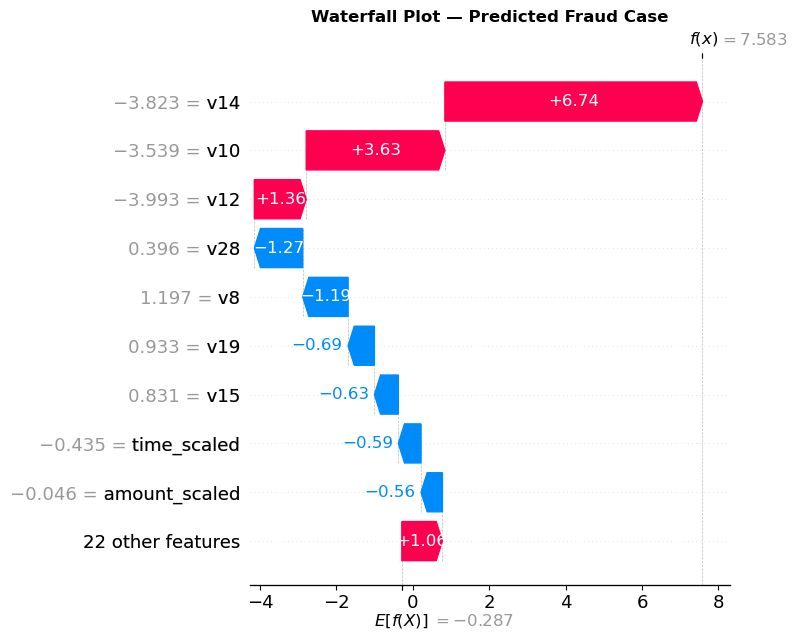

In [86]:
# --- Waterfall: Fraud case ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values       = shap_values[fraud_pos],
        base_values  = explainer.expected_value,
        data         = X_test.iloc[fraud_pos],
        feature_names= X_test.columns.tolist()
    ),
    show=False
)
plt.title("Waterfall Plot — Predicted Fraud Case", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_waterfall_fraud.png", dpi=150, bbox_inches="tight")
plt.show()

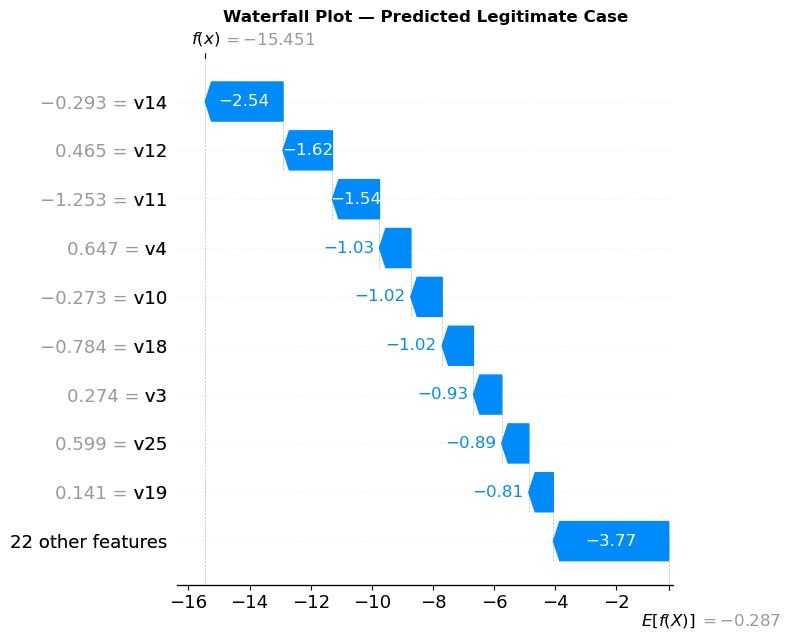

In [87]:
# --- Waterfall: Legitimate case ---
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values       = shap_values[legit_pos],
        base_values  = explainer.expected_value,
        data         = X_test.iloc[legit_pos],
        feature_names= X_test.columns.tolist()
    ),
    show=False
)
plt.title("Waterfall Plot — Predicted Legitimate Case", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_waterfall_legit.png", dpi=150, bbox_inches="tight")
plt.show()

*After fraud waterfall*
> **Fraud case breakdown** (f(x) = 7.583, base = −0.287):
>
> Three features drove this prediction to fraud:
> - `v14 = −3.823` contributed **+6.74** as the single largest push. A deeply 
>   negative v14 value is the model's strongest fraud trigger, consistent with 
>   the beeswarm pattern observed in Section 8.
> - `v10 = −3.539` added **+3.63**, marking a strong secondary fraud signal.
> - `v12 = −3.993` added **+1.36**, serving as a third confirming signal, all three 
>   features unusually negative together.
>
> Counterbalancing features (`v28`, `v8`, `v19`) pushed toward legitimate 
> but were not strong enough to overcome the fraud signals. The model's 
> final score of **7.583** is far above any fraud threshold, making this 
> a high-confidence fraud prediction.


*After legitimate waterfall*
> **Legitimate case breakdown** (f(x) = −15.451, base = −0.287):
>
> Every top feature pushed firmly toward legitimate, with no single feature 
> was working against the others:
> - `v14 = −0.293` contributed **−2.54**; even though v14 is slightly 
>   negative here, it is far less extreme than the fraud case (−3.823), 
>   so the model correctly treats it as non-fraudulent.
> - `v12`, `v11`, `v4`, `v10`, `v18` all contributed negatively, 
>   reinforcing each other.
>
> The final score of **−15.451** is an extremely confident legitimate 
> prediction. The contrast with the fraud case illustrates exactly what 
> the model learned: fraud cases have extreme, co-occurring negative 
> values in v14, v10, and v12 simultaneously.

### **9.2 Dependence Plot: v14 and v4**

The dependence plots below show how `v14` and `v4`'s SHAP values change across 
their range of raw values. Each dot is one test sample. The colour encodes a 
second feature (auto-selected by SHAP as the strongest interacting variable,
`v11` in both cases), revealing whether the effect of each feature changes 
depending on another variable.

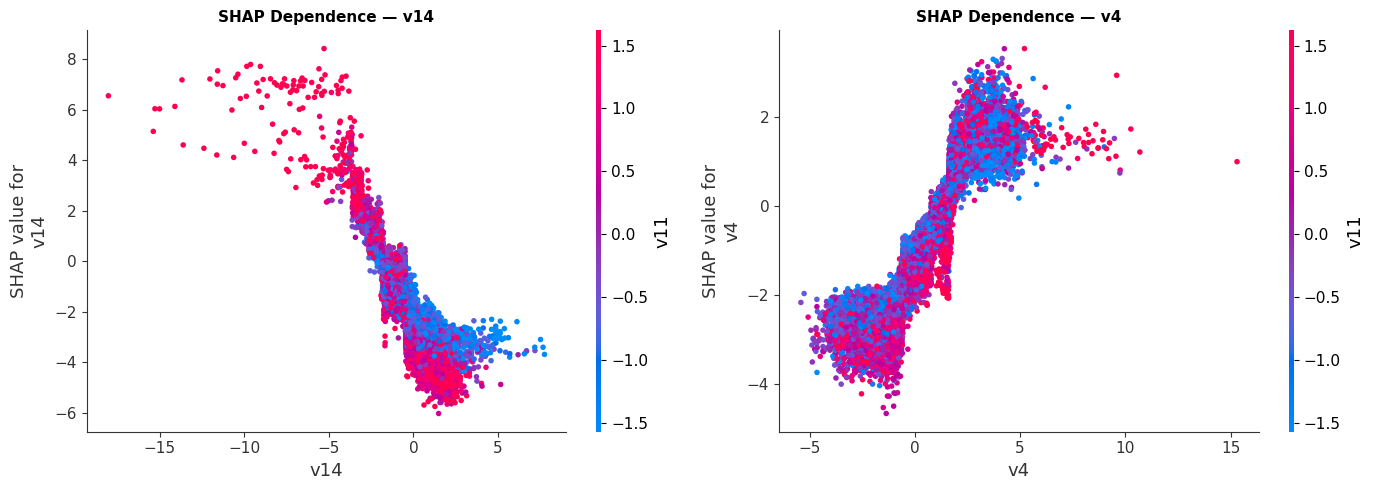

In [88]:
# Dependence plot for v14 and v4 (top two features)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature in zip(axes, ["v14", "v4"]):
    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        ax=ax,
        show=False
    )
    ax.set_title(f"SHAP Dependence — {feature}", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

> **v14 - Threshold behaviour:**
> When `v14 < -5`, SHAP values spike to **+4 to +8**, indicating
> high-confidence fraud cases, consistent with the waterfall plot where 
> `v14 = -3.823` alone contributed +6.74 toward fraud. As v14 moves toward 
> zero, SHAP drops sharply. When `v14 > 0`, SHAP turns negative and the model 
> is confident the transaction is legitimate. `v14` acts like a **threshold 
> switch**: cross a certain value and fraud risk jumps dramatically.

> **v4 - Continuous risk scaler:**
> `v4` shows a smooth monotonic curve where the higher the value, the higher 
> the SHAP contribution toward fraud. Unlike v14's sharp threshold, v4 
> scales risk gradually across its entire range. High positive v4 values 
> (>5) push strongly toward fraud while negative values push firmly toward 
> legitimate.

> **Interaction (colour = v11):** At the same v14 value, different v11 
> values produce slightly different SHAP outputs, visible as colour 
> variation within the same vertical band. This confirms a mild interaction 
> between v14 and v11 that the model has learned.

---
**Section takeaway:** Individual SHAP explanations make the model fully 
auditable. Any flagged transaction can be traced back to the exact features 
and values that triggered the alert, which is a critical requirement for 
real-world fraud detection systems where decisions must be justifiable.

## **10. Business Recommendations**

The model achieves strong fraud detection performance, but the value of this 
analysis lies in translating model findings into decisions a fraud team can act on.


### **10.1 Deploy v14 and v4 as Primary Alert Triggers**

`v14` is the single strongest fraud signal in the dataset. Transactions where 
`v14 < -5` should be flagged for immediate review, as the model assigns these 
SHAP values of +4 to +8, making them near-certain fraud cases. `v4` serves as 
a continuous risk scaler; high positive values should elevate a transaction's 
risk score even when v14 is not extreme.

A two-stage alert system is recommended:

| Stage | Condition | Action |
|-------|-----------|--------|
| **Auto-block** | v14 < -5 AND v4 > 5 together | Block transaction immediately |
| **Manual review** | Either condition alone, or v12 and v10 both extreme | Queue for investigator |

### **10.2 Maintain the Tuned Threshold**

The default 0.5 threshold optimises for accuracy, not recall. In fraud 
detection, missing a fraud case is far costlier than a false alarm. The tuned 
threshold applied in Section 7 improved recall on the fraud class while keeping 
precision at 0.94, meaning 94% of flagged transactions are genuine fraud.

Reverting to the default threshold in production would increase missed fraud 
cases. The tuned threshold should be treated as a business decision, not just 
a technical one, and re-evaluated periodically as fraud patterns shift.

### **10.3 Monitor amount_scaled and time_scaled**

These are the only two interpretable features in the top 15. While their 
individual SHAP contributions are smaller than the PCA components, they provide 
human-readable context for fraud investigators reviewing flagged cases.

Raw transaction amount and time of day should be included in all fraud alert 
reports alongside model scores, so investigators can quickly assess plausibility 
without needing to decode PCA components.

### **10.4 Retrain Regularly**

The dataset is static and historical. Real-world fraud patterns evolve as 
fraudsters adapt to detection systems. A model trained once will degrade over 
time as the distribution of v14, v4, and other features drifts.

Monthly retraining on rolling transaction windows is recommended. Recall on 
the fraud class should be tracked as the primary production metric, with 
retraining triggered if it drops below 0.85.

### **10.5 Cost-Benefit Framing**

With approximately 284,000 transactions and only 492 fraud cases, the cost 
asymmetry is extreme. A single missed fraud case typically costs far more than 
investigating several false positives. The model's high recall ensures most 
fraud is caught, while precision of 0.94 keeps the investigation workload 
manageable.

The business should assign explicit cost values to false negatives (missed fraud) 
and false positives (wasted investigation time), then optimise the threshold 
mathematically against that cost function rather than using a fixed value.

---

## **11. Conclusion**

This project delivered a complete end-to-end fraud detection pipeline on a 
highly imbalanced credit card transaction dataset, covering every stage from 
raw data to explainable predictions.

### **11.1 Pipeline Summary**

| Stage | Approach |
|-------|----------|
| Data cleaning | Sentinel value removal, scaling of Amount and Time |
| Class imbalance | `class_weight='balanced'` and `scale_pos_weight` — penalises fraud misclassification without resampling |
| Model selection | XGBoost chosen for performance and interpretability |
| Evaluation | ROC-AUC, precision, recall, F1 on held-out test set |
| Threshold tuning | Custom threshold to maximise fraud class recall |
| Explainability | SHAP global importance, waterfall, and dependence plots |

### **11.2 Key Results**

- The model achieved a **ROC-AUC of 0.9725** on the held-out test set
- Threshold tuning improved fraud recall while maintaining precision of 0.94
- `v14` emerged as the dominant fraud feature, contributing more predictive 
  power than the next several features combined
- SHAP analysis confirmed that extremely negative `v14` values and high 
  positive `v4` values are the primary fraud signatures in this dataset

### **11.3 Limitations**

- **Anonymised features:** All PCA components (v1-v28) have no business 
  interpretation, making stakeholder communication harder without raw data access
- **Static dataset:** The model was trained and tested on historical data only. 
  Real-world performance will degrade as fraud patterns evolve
- **No deployment pipeline:** This notebook covers modelling only. A production 
  system would require an API, real-time scoring, and monitoring infrastructure

### **11.4 Future Improvements**

- Train on raw (non-PCA) features if access is available, to enable direct 
  business interpretation of model decisions
- Explore LightGBM and CatBoost as alternatives to XGBoost for speed and 
  categorical feature handling
- Implement a cost-sensitive learning framework where misclassification costs 
  are built directly into the loss function
- Build a real-time scoring API using FastAPI or Flask, wrapping the trained 
  XGBoost model and SHAP explainer

---

*Project completed: Credit Card Fraud Detection using XGBoost and SHAP, implementing a complete machine learning 
pipeline from handling imbalanced raw data to generating explainable fraud predictions.*